In [3]:
# ─────────────────────────────────────────────
# [C1] Part 0 · ⚙️ 환경 설정과 실습 데이터
# 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정 (실행하면 버전과 폰트가 출력됩니다)
# ─────────────────────────────────────────────
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

warnings.filterwarnings("ignore")

# 오늘 쓰는 도구를 미리 불러옵니다 (순서 실행 안전)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
)

# 재현성: 같은 난수를 항상 같게 만듭니다.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 한글 폰트 설정 — 그래프의 한글이 □□□로 깨지지 않게 합니다
system = platform.system()
if system == "Darwin":                      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True,
                       capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

print("환경 준비 완료!")
import sklearn
print(f"- scikit-learn {sklearn.__version__}")
print(f"- 그래프 한글 폰트: {plt.rcParams['font.family'][0]}")

환경 준비 완료!
- scikit-learn 1.9.0
- 그래프 한글 폰트: Malgun Gothic


In [4]:
# ─────────────────────────────────────────────
# [C2] Part 0 · ⚙️ 환경 설정과 실습 데이터
# 실습 데이터 준비 — 모두플레이 구독자 3,000명 + 이탈 정의 2종(90일 / 30일)
# (실행하면 두 정의의 이탈 비율이 출력됩니다)
# ─────────────────────────────────────────────
# 열 이름은 지난 시간들과 같습니다. 이탈 비율을 우리가 정해야
# '정확도의 거짓말'을 시연할 수 있으므로 합성으로 만듭니다
FEATURES = ["tenure_months", "watch_hours_last_month", "avg_daily_watch_min",
            "avg_session_min", "days_since_last_watch", "titles_started",
            "completion_rate", "support_tickets", "device_count", "monthly_fee"]

# 이탈 판정의 기준선(절편) — 작을수록 이탈로 판정되는 고객이 줄어듭니다
BASE_90D = 1.15       # "90일 안에 해지" → 이탈률 약 33%
BASE_30D = -1.188     # "30일 안에 해지" → 이탈률 약 10%


def make_moduplay(n=3000, seed=RANDOM_STATE, churn_base=BASE_30D):
    """모두플레이 구독자 데이터. 같은 고객에게 이탈 라벨을 여러 개 답니다.

    churn_90d / churn_30d — "언제까지 해지하면 이탈로 볼 것인가"의 차이입니다.
    churn — churn_base로 비율을 직접 지정한 라벨. (실무에서는 pd.read_csv 자리)
    """
    rng = np.random.default_rng(seed)
    engagement = rng.beta(2.2, 2.2, n)      # 서비스에 붙어 있는 정도(관측 불가)

    tenure = rng.integers(1, 49, n)
    watch_h = np.clip(rng.normal(5 + 40 * engagement, 5.5, n), 0.3, None)
    avg_daily = np.clip(watch_h * 60 / 30 + rng.normal(0, 2.0, n), 0.5, None)
    avg_session = np.clip(rng.normal(18 + 75 * engagement, 11, n), 4, None)
    days_since = np.clip(rng.poisson(0.8 + 17 * (1 - engagement) ** 1.5, n), 0, 30)
    titles = rng.poisson(1.5 + 24 * engagement, n)
    completion = np.clip(rng.normal(0.22 + 0.55 * engagement, 0.11, n), 0.02, 1.0)
    tickets = rng.poisson(0.25 + 1.3 * (1 - engagement), n)
    devices = 1 + rng.binomial(3, 0.15 + 0.55 * engagement, n)
    fee = rng.choice([9900, 14900, 19900], n, p=[0.45, 0.35, 0.20])

    df = pd.DataFrame({
        "tenure_months": tenure,
        "watch_hours_last_month": watch_h.round(1),
        "avg_daily_watch_min": avg_daily.round(1),
        "avg_session_min": avg_session.round(1),
        "days_since_last_watch": days_since,
        "titles_started": titles,
        "completion_rate": completion.round(3),
        "support_tickets": tickets,
        "device_count": devices,
        "monthly_fee": fee,
    })

    # 이탈 위험 점수 — 기준선을 뺀 나머지. 모든 정의가 이 점수를 공유합니다
    risk = (0.175 * df["days_since_last_watch"]
            - 0.070 * df["watch_hours_last_month"]
            - 2.10 * df["completion_rate"]
            + 0.38 * df["support_tickets"]
            - 0.028 * df["tenure_months"]
            - 0.20 * df["device_count"]
            + rng.normal(0, 0.55, n))

    # 동전 하나를 여러 정의가 함께 씁니다
    # → 30일 안에 해지한 고객은 90일 안에도 반드시 해지한 것이 됩니다(포함관계 보장)
    coin = rng.random(n)

    def judge(base):
        return (coin < 1 / (1 + np.exp(-(base + risk)))).astype(int)

    df["churn_90d"] = judge(BASE_90D)
    df["churn_30d"] = judge(BASE_30D)
    df["churn"] = judge(churn_base)
    return df


moduplay = make_moduplay()

# 학습/테스트 분리는 한 번만 합니다 — 두 정의가 똑같은 고객 분할을 공유합니다
train_df, test_df = train_test_split(
    moduplay, test_size=0.25, random_state=RANDOM_STATE,
    stratify=moduplay["churn_30d"])          # 더 희귀한 정의에 맞춰 계층 분할

X_tr, X_te = train_df[FEATURES], test_df[FEATURES]
y90_tr, y90_te = train_df["churn_90d"], test_df["churn_90d"]   # Part 1~2에서 씁니다
y_tr, y_te = train_df["churn_30d"], test_df["churn_30d"]       # Part 3~5에서 씁니다
X, y = moduplay[FEATURES], moduplay["churn_30d"]

print(f"모두플레이 구독자 {len(moduplay):,}명 | 학습 {len(train_df):,} / 테스트 {len(test_df)}")
print()
print("[정의 A] 90일 안에 해지 = 이탈")
print(f"    이탈 비율 {moduplay['churn_90d'].mean():.3f}   (테스트 이탈 {int(y90_te.sum())}명)")
print("[정의 B] 30일 안에 해지 = 이탈")
print(f"    이탈 비율 {moduplay['churn_30d'].mean():.3f}   (테스트 이탈 {int(y_te.sum())}명)")
print()
broken = int(((moduplay["churn_30d"] == 1) & (moduplay["churn_90d"] == 0)).sum())
print(f"30일 이탈자인데 90일 이탈자가 아닌 사람: {broken}명 (0이어야 정상입니다)")
print("→ 같은 고객, 같은 행동입니다. 정의만 좁혔더니 이탈이 33%에서 10%로 줄었습니다.")

모두플레이 구독자 3,000명 | 학습 2,250 / 테스트 750

[정의 A] 90일 안에 해지 = 이탈
    이탈 비율 0.330   (테스트 이탈 241명)
[정의 B] 30일 안에 해지 = 이탈
    이탈 비율 0.100   (테스트 이탈 75명)

30일 이탈자인데 90일 이탈자가 아닌 사람: 0명 (0이어야 정상입니다)
→ 같은 고객, 같은 행동입니다. 정의만 좁혔더니 이탈이 33%에서 10%로 줄었습니다.


In [5]:
# ─────────────────────────────────────────────
# [C3] Part 1 · 📊 데이터로 확인해 봅시다 — 90일 정의의 혼동행렬
# 90일 정의로 학습 → 혼동행렬 네 칸 (실행하면 TN·FP·FN·TP가 출력됩니다)
# ─────────────────────────────────────────────
# 로지스틱 회귀는 피처 크기에 민감하므로 스케일 조정과 묶어 학습합니다
model_90 = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
).fit(X_tr, y90_tr)

pred_90 = model_90.predict(X_te)

cm_90 = confusion_matrix(y90_te, pred_90)
tn, fp, fn, tp = cm_90.ravel()      # 순서 주의: TN, FP, FN, TP

print("혼동행렬 (행=실제, 열=예측)")
print(cm_90)
print()
print(f"  TP(이탈을 제대로 찾음) = {tp}")
print(f"  FP(헛경보)             = {fp}")
print(f"  FN(놓침)               = {fn}")
print(f"  TN(유지를 제대로 넘김) = {tn}")
print()
print(f"→ 정확도 = (TP+TN)/전체 = ({tp}+{tn})/{len(y90_te)} = {accuracy_score(y90_te, pred_90):.3f}")
print(f"  틀린 것은 {fp + fn}개이고, 헛경보 {fp}개와 놓침 {fn}개로 나뉩니다.")

혼동행렬 (행=실제, 열=예측)
[[448  61]
 [ 74 167]]

  TP(이탈을 제대로 찾음) = 167
  FP(헛경보)             = 61
  FN(놓침)               = 74
  TN(유지를 제대로 넘김) = 448

→ 정확도 = (TP+TN)/전체 = (167+448)/750 = 0.820
  틀린 것은 135개이고, 헛경보 61개와 놓침 74개로 나뉩니다.


🎯 [C3] 확인하기
정확도 0.820입니다. 그런데 틀린 것이 135개나 됩니다 — 헛경보(FP) 61개, 놓침(FN) 74개. 두 실수의 크기가 서로 다르고, 놓침이 헛경보보다 많습니다.

정확도 0.820은 이 숫자만 보면 양호해 보일 수 있습니다. 하지만 네 칸을 열어 보니 이탈할 고객 74명을 놓쳤다는 사실이 드러납니다. 정확도라는 한 숫자만 봤다면 이 74명은 끝까지 보이지 않았습니다.

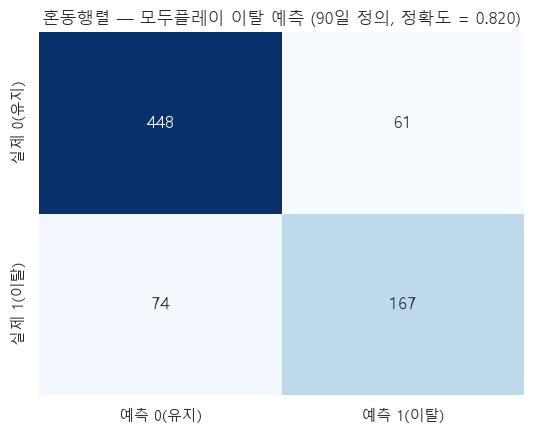

→ 대각선(왼쪽 위 ↘ 오른쪽 아래)이 맞힌 칸, 나머지 두 칸이 서로 다른 두 실수입니다.


In [6]:
# ─────────────────────────────────────────────
# [C4] Part 1 · 📊 데이터로 확인해 봅시다 — 90일 정의의 혼동행렬
# 혼동행렬 히트맵 (실행하면 네 칸이 색으로 구분된 격자가 그려집니다)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm_90, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["예측 0(유지)", "예측 1(이탈)"],
            yticklabels=["실제 0(유지)", "실제 1(이탈)"], ax=ax)
ax.set_title("혼동행렬 — 모두플레이 이탈 예측 (90일 정의, "
             f"정확도 = {accuracy_score(y90_te, pred_90):.3f})")
plt.tight_layout()
plt.show()

print("→ 대각선(왼쪽 위 ↘ 오른쪽 아래)이 맞힌 칸, 나머지 두 칸이 서로 다른 두 실수입니다.")

👀 [C4] 결과읽기
진한 칸이 개수가 많은 칸입니다. 왼쪽 위 TN(448)이 가장 진하고 오른쪽 아래 TP(167)가 그다음입니다. 대각선이 진하고 나머지 두 칸이 옅으면 좋은 모델입니다. 분류 모델을 평가할 때는 정확도와 함께 혼동행렬을 확인해야 오류의 종류를 구분할 수 있습니다.

⌨️ 백문이 불여일타! (1)
[문제]
1) [C3]에서 얻은 `tn`, `fp`, `fn`, `tp` 네 변수로 정확도를 직접 계산합니다.
   (accuracy_score를 쓰지 말고 네 칸의 나눗셈으로만)
2) 계산한 값이 `accuracy_score(y90_te, pred_90)`와 같은지 확인합니다.
3) 만약 이 모델이 FN(놓침)만 40개 더 늘고 TP가 40개 줄었다고 가정하면,
   정확도와 재현율(TP/(TP+FN))은 각각 얼마가 될까요? 각각 0.766 /0.526
   어느 쪽이 더 크게 반응합니까? 재현율이 더 크게 반응. 분모에 TP+FN 밖에 없음

In [7]:
# [C5] Part 1 · ⌨️ 백문이 불여일타! (1)
# ⌨️ 백문이 불여일타! (1) — 네 칸으로 정확도 직접 계산

# (tn, fp, fn, tp 는 [C3]에서 만들어 둔 그대로입니다)

# 여기에 코드를 작성하세요

handmade_accuracy = (tp + tn) / (tp + fp + fn + tn)
print(handmade_accuracy)
print(accuracy_score(y90_te, pred_90))

# 만약 이 모델이 FN(놓침)만 40개 더 늘고 TP가 40개 줄었다고 가정하면,
# 정확도보다 재현율이 더 크게 반응할 것.

# fn(놓침, 음성이라 예측했지만 틀림) 40개 늘고 tp 40개 줄었을 때
handmade_recall = tp / (tp + fn)
fn_new = fn + 40
tp_new = tp - 40
handmade_accuracy_new = (tp_new + tn) / (tp_new + fp + fn_new + tn)
print(handmade_accuracy_new)

handmade_recall_new = tp_new / (tp_new + fn_new)
print(handmade_recall_new)



0.82
0.82
0.7666666666666667
0.5269709543568465


In [8]:
# ─────────────────────────────────────────────
# [C6] Part 2 · 📊 데이터로 확인해 봅시다 — 네 칸에서 지표를 손으로 계산
# 정밀도·재현율·F1을 정의대로 계산 → sklearn 결과와 대조 (실행하면 두 값이 나란히 출력됩니다)
# ─────────────────────────────────────────────
# 손계산 — 정의 그대로
precision_manual = tp / (tp + fp)
recall_manual = tp / (tp + fn)
f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)

print("네 칸:", f"TN={tn} FP={fp} FN={fn} TP={tp}")
print()
print(f"정밀도 = TP/(TP+FP) = {tp}/({tp}+{fp}) = {precision_manual:.4f}")
print(f"재현율 = TP/(TP+FN) = {tp}/({tp}+{fn}) = {recall_manual:.4f}")
print(f"F1     = 2PR/(P+R)                = {f1_manual:.4f}")
print()
print("sklearn 값과 대조")
print(f"  precision_score = {precision_score(y90_te, pred_90):.4f}")
print(f"  recall_score    = {recall_score(y90_te, pred_90):.4f}")
print(f"  f1_score        = {f1_score(y90_te, pred_90):.4f}")
print()
print("→ 손계산과 sklearn이 정확히 일치합니다. 지표는 네 칸의 나눗셈일 뿐입니다.")

네 칸: TN=448 FP=61 FN=74 TP=167

정밀도 = TP/(TP+FP) = 167/(167+61) = 0.7325
재현율 = TP/(TP+FN) = 167/(167+74) = 0.6929
F1     = 2PR/(P+R)                = 0.7122

sklearn 값과 대조
  precision_score = 0.7325
  recall_score    = 0.6929
  f1_score        = 0.7122

→ 손계산과 sklearn이 정확히 일치합니다. 지표는 네 칸의 나눗셈일 뿐입니다.


In [9]:
# ─────────────────────────────────────────────
# [C7] Part 2 · 📊 데이터로 확인해 봅시다 — 네 칸에서 지표를 손으로 계산
# classification_report — 클래스별 지표를 한 표로 (실행하면 지표 표가 출력됩니다)
# ─────────────────────────────────────────────
print(classification_report(
    y90_te, pred_90,
    target_names=["0 (유지)", "1 (이탈)"],
    digits=3,
))
print("support = 각 클래스의 실제 개수입니다. 지표를 해석할 때 반드시 함께 보세요.")

              precision    recall  f1-score   support

      0 (유지)      0.858     0.880     0.869       509
      1 (이탈)      0.732     0.693     0.712       241

    accuracy                          0.820       750
   macro avg      0.795     0.787     0.791       750
weighted avg      0.818     0.820     0.819       750

support = 각 클래스의 실제 개수입니다. 지표를 해석할 때 반드시 함께 보세요.


👀 [C7] 결과읽기
각 행이 클래스별 지표입니다. 1 (이탈) 행의 precision·recall이 방금 손계산한 값입니다. 0 (유지) 행은 관점을 뒤집어 유지 고객을 찾는 문제로 본 지표입니다 — 같은 혼동행렬에서 계산 방향만 바꾼 것입니다. 유지 쪽 점수가 더 높은 이유는 그 클래스가 두 배 이상 많기 때문입니다(support 509 대 241).

[문제]
1) 아래 가상의 혼동행렬 두 개를 각각 손으로 계산해 정밀도·재현율·F1을 구합니다.
   모델 A: TP=90, FP=10, FN=10, TN=890
   모델 B: TP=50, FP=0,  FN=50, TN=900
2) 두 모델의 정확도를 각각 구합니다. 정확도로는 어느 쪽이 더 좋아 보입니까?
3) 만약 이것이 "암 진단 선별검사"라면 어느 모델을 택해야 할까요? 이유를 한 줄로 적습니다.

In [10]:
# [C8] Part 2 · ⌨️ 백문이 불여일타! (2)
# ⌨️ 백문이 불여일타! (2) — 두 모델을 지표로 비교하고 상황에 맞게 선택

A_TP, A_FP, A_FN, A_TN = 90, 10, 10, 890
B_TP, B_FP, B_FN, B_TN = 50, 0, 50, 900

A_accuracy = (A_TP + A_TN) / (A_TP + A_TN + A_FP + A_FN)
B_accuracy = (B_TP + B_TN) / (B_TP + B_TN + B_FP + B_FN)

print(f"A 정확도 = {A_accuracy:.3f}")
print(f"B 정확도 = {B_accuracy:.3f}")

print("정확도만 보면 A 모델이 좋아보임.")

A 정확도 = 0.980
B 정확도 = 0.950
정확도만 보면 A 모델이 좋아보임.


In [11]:
# 암 진단이었다면 -> 재현율을 봐야지 실제 양성인 경우를
A_recall = A_TP / (A_TP + A_FN)
B_recall = B_TP / (B_TP + B_FN)
print(f"A 재현율 = {A_recall:.3f}")
print(f"B 재현율 = {B_recall:.3f}")

print("재현율만 보면 A 모델이 좋아보임.")
print("실제 양성인 경우를 놓치지 않는 것이 중요할 때는 재현율을 봐야 함.")

A 재현율 = 0.900
B 재현율 = 0.500
재현율만 보면 A 모델이 좋아보임.
실제 양성인 경우를 놓치지 않는 것이 중요할 때는 재현율을 봐야 함.


In [13]:
# ─────────────────────────────────────────────
# [C9] Part 3 · 📊 데이터로 확인해 봅시다 — 거짓말을 눈으로
# 무조건 다수 찍기 vs 제대로 학습한 모델 (실행하면 두 모델의 지표가 나란히 출력됩니다)
# ─────────────────────────────────────────────
# ① 아무것도 배우지 않은 모델 — 무조건 다수 클래스(유지)로 찍기
dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
pred_dummy = dummy.predict(X_te)

# ② 제대로 학습한 로지스틱 회귀
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
).fit(X_tr, y_tr)
pred = model.predict(X_te)
proba = model.predict_proba(X_te)[:, 1]     # 이탈 확률 (Part 5에서 다시 씁니다)

rows = []
for name, p in [("① 무조건 다수(유지)로 찍기", pred_dummy), ("② 로지스틱 회귀", pred)]:
    rows.append({
        "모델": name,
        "정확도": accuracy_score(y_te, p),
        "정밀도": precision_score(y_te, p, zero_division=0),
        "재현율": recall_score(y_te, p),
        "F1": f1_score(y_te, p, zero_division=0),
    })
compare = pd.DataFrame(rows)
print(compare.round(3).to_string(index=False))
print()
print(f"참고 — 테스트셋 이탈 비율 = {y_te.mean():.3f}  (다수 클래스 비율 = {1 - y_te.mean():.3f})")
print(f"→ ①의 정확도는 다수 클래스 비율과 정확히 같습니다. 아무것도 배우지 않았는데도요.")

              모델   정확도   정밀도  재현율    F1
① 무조건 다수(유지)로 찍기 0.900 0.000 0.00 0.000
       ② 로지스틱 회귀 0.916 0.667 0.32 0.432

참고 — 테스트셋 이탈 비율 = 0.100  (다수 클래스 비율 = 0.900)
→ ①의 정확도는 다수 클래스 비율과 정확히 같습니다. 아무것도 배우지 않았는데도요.


🎯 [C9] 확인하기
① 무조건 유지로 찍기 — 정확도 0.900. 그런데 재현율은 0.000입니다. 이탈 고객을 단 한 명도 찾지 못했습니다. 그래도 정확도는 90%입니다. 사막의 예언가와 똑같습니다.

② 로지스틱 회귀 — 정확도 0.916. ①보다 겨우 +0.016입니다. 그런데 재현율은 0.320입니다.

여기서 잠깐 멈춰 생각합니다. 마케팅팀에 "정확도 92% 모델을 만들었습니다"라고 보고하면 어떤 반응이 올까요? 높은 성능으로 받아들일 수 있습니다. 하지만 진실은 재현율 0.320으로, 실제 이탈 고객의 약 68%를 놓치고 있다는 것입니다.

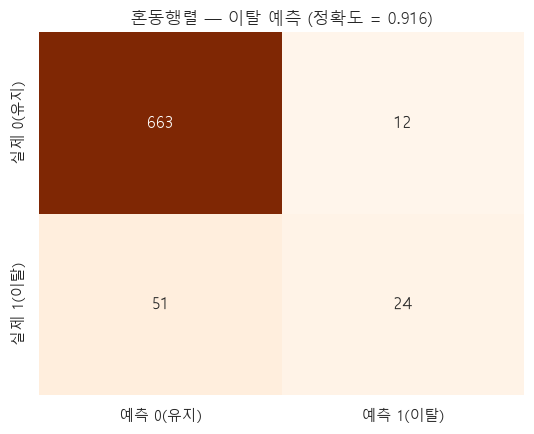

실제 이탈 고객 75명 중
  찾아낸 고객(TP)  = 24명
  놓친 고객(FN)    = 51명  ← 전체 이탈자의 68%
헛경보(FP)         = 12명  (쿠폰 낭비)

→ 정확도 0.916이라는 숫자에 이 51명이 숨어 있었습니다.


In [14]:
# ─────────────────────────────────────────────
# [C10] Part 3 · 📊 데이터로 확인해 봅시다 — 거짓말을 눈으로
# 불균형 데이터의 혼동행렬 — 놓침이 몇 명인지 (실행하면 격자와 놓침 인원이 출력됩니다)
# ─────────────────────────────────────────────
cm = confusion_matrix(y_te, pred)
tn_i, fp_i, fn_i, tp_i = cm.ravel()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False,
            xticklabels=["예측 0(유지)", "예측 1(이탈)"],
            yticklabels=["실제 0(유지)", "실제 1(이탈)"], ax=ax)
ax.set_title(f"혼동행렬 — 이탈 예측 (정확도 = {accuracy_score(y_te, pred):.3f})")
plt.tight_layout()
plt.show()

churner = tp_i + fn_i
print(f"실제 이탈 고객 {churner}명 중")
print(f"  찾아낸 고객(TP)  = {tp_i}명")
print(f"  놓친 고객(FN)    = {fn_i}명  ← 전체 이탈자의 {fn_i / churner * 100:.0f}%")
print(f"헛경보(FP)         = {fp_i}명  (쿠폰 낭비)")
print()
print(f"→ 정확도 {accuracy_score(y_te, pred):.3f}이라는 숫자에 이 {fn_i}명이 숨어 있었습니다.")

👀 [C10] 결과읽기
왼쪽 위 칸(TN=663)만 압도적으로 진합니다. 정확도의 분자를 이 칸이 거의 다 채우고 있다는 뜻입니다. 정작 우리가 관심 있는 오른쪽 아래 칸(TP=24)은 아주 옅고, 그 왼쪽의 놓침(FN=51)이 그보다 두 배 넘게 큽니다.

숫자로 정리하면 이렇습니다 — 실제 이탈 고객 75명 중 51명(68%)을 놓쳤습니다. 반대로 헛경보는 12명뿐입니다. 모델이 양성 예측을 보수적으로 내고 있습니다. 높은 점수를 받은 관측치만 "이탈"로 분류한 결과입니다.

그래서 정밀도는 0.667 — 재현율(0.320)의 두 배가 넘습니다. 양성 예측 범위가 좁으면 정밀도가 재현율보다 높게 나타날 수 있습니다. 그러나 이 차이만으로 모델의 품질을 단정할 수 없으며 운영 목적과 함께 판단해야 합니다. 지목한 36명 중 24명은 맞혔지만, 실제 이탈 고객 75명 중 51명은 음성으로 분류했습니다.

[문제]
1) 이탈률이 각각 30%, 10%, 1%, 0.1%인 데이터가 있다고 가정합니다.
   각 경우에 "무조건 다수로 찍기"의 정확도를 계산해 출력합니다.
2) 만약 어떤 팀이 "이탈 예측 모델 정확도 98%를 달성했다"고 보고했습니다.
   이 보고만으로 판단할 수 없는 이유를, 1번 결과를 근거로 한 줄 적습니다.
3) 그 팀에게 되물어야 할 질문 2개를 적습니다.

In [ ]:
# [C11] Part 3 · ⌨️ 백문이 불여일타! (3)
# ⌨️ 백문이 불여일타! (3) — 다수 클래스 비율이라는 숨은 출발선

churn_rates = [0.30, 0.10, 0.01, 0.001]

# 여기에 코드를 작성하세요
for rate in churn_rates:
    print(f"이탈률 {rate:.3f} → 무조건 다수로 찍기 정확도 = {1 - rate:.3f}")

이탈률 0.300 → 무조건 다수로 찍기 정확도 = 0.700
이탈률 0.100 → 무조건 다수로 찍기 정확도 = 0.900
이탈률 0.010 → 무조건 다수로 찍기 정확도 = 0.990
이탈률 0.001 → 무조건 다수로 찍기 정확도 = 0.999


2) 만약 어떤 팀이 "이탈 예측 모델 정확도 98%를 달성했다"고 보고했습니다.
   이 보고만으로 판단할 수 없는 이유를, 1번 결과를 근거로 한 줄 적습니다.

불균형 데이터에서 소수 클래스 탐지가 중요하다면 정확도만 보고하지 않고 혼동행렬·정밀도·재현율을 함께 확인해야 합니다.

3) 그 팀에게 되물어야 할 질문 2개를 적습니다.

- 재현율은요?
- 정밀도는요?# ─────────────────────────────────────────────

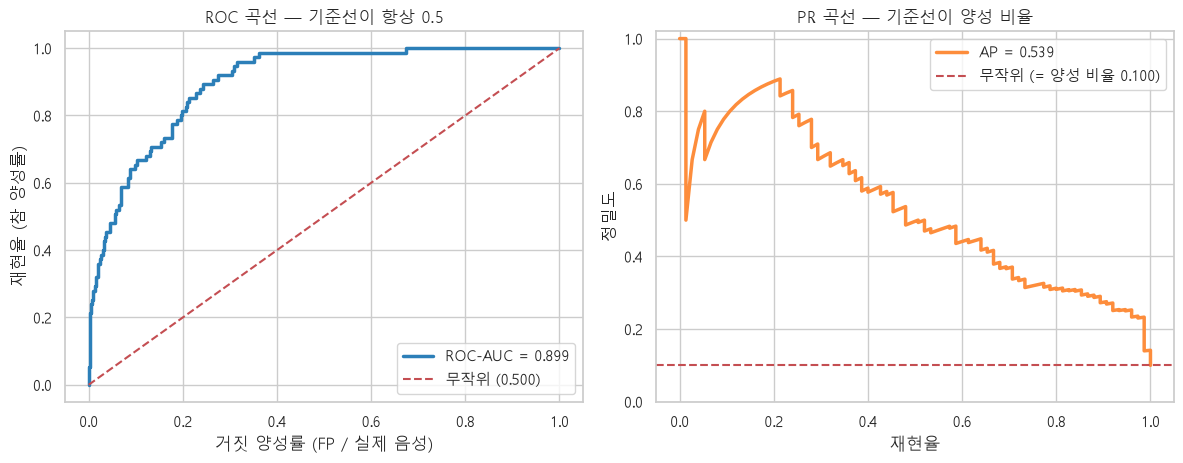

ROC-AUC = 0.899   (무작위 기준선 0.500 → 기준선의 1.8배)
AP      = 0.539   (양성 비율 0.100)


In [18]:
# ─────────────────────────────────────────────
# [C12] Part 4 · 📊 데이터로 확인해 봅시다 — 같은 모델, 두 곡선
# ROC곡선과 PR곡선을 나란히 (실행하면 두 곡선과 각각의 면적 점수가 나옵니다)
# ─────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_te, proba)
prec, rec, _ = precision_recall_curve(y_te, proba)

roc_auc = roc_auc_score(y_te, proba)
ap = average_precision_score(y_te, proba)
baseline = y_te.mean()          # PR곡선의 무작위 기준선 = 양성 비율

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(fpr, tpr, lw=2.5, color="#2c7fb8", label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "r--", lw=1.5, label="무작위 (0.500)")
axes[0].set_xlabel("거짓 양성률 (FP / 실제 음성)")
axes[0].set_ylabel("재현율 (참 양성률)")
axes[0].set_title("ROC 곡선 — 기준선이 항상 0.5")
axes[0].legend(loc="lower right")

axes[1].plot(rec, prec, lw=2.5, color="#fd8d3c", label=f"AP = {ap:.3f}")
axes[1].axhline(baseline, color="r", ls="--", lw=1.5,
                label=f"무작위 (= 양성 비율 {baseline:.3f})")
axes[1].set_xlabel("재현율")
axes[1].set_ylabel("정밀도")
axes[1].set_ylim(0, 1.02)
axes[1].set_title("PR 곡선 — 기준선이 양성 비율")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

print(f"ROC-AUC = {roc_auc:.3f}   (무작위 기준선 0.500 → 기준선의 {roc_auc / 0.5:.1f}배)")
print(f"AP      = {ap:.3f}   (양성 비율 {baseline:.3f})")

🎯 [C12] 확인하기
ROC-AUC는 0.899입니다. 이 값은 모델이 임의의 양성 표본에 임의의 음성 표본보다 높은 점수를 부여할 가능성이 크다는 뜻입니다. 반면 임계값 0.5에서의 재현율은 0.320입니다. 
순위 구분 능력이 좋아도 기본 운영점이 적절하다는 뜻은 아닙니다. <이해안감>

[C12]에서 average_precision_score로 계산한 평균 정밀도(AP)는 0.539이고, 양성 비율 0.100보다 높습니다. AP(평균 정밀도)와 ROC-AUC는 축과 계산 방식이 다르므로 값의 크기나 기준선 대비 배수를 서로 직접 비교하지 않습니다.

⚠️ 주의하기 — AP와 PR-AUC
이 노트북의 코드는 scikit-learn의 평균 정밀도(AP)를 사용합니다. AP는 재현율 증가분으로 정밀도를 가중해 PR 곡선을 요약합니다. 사다리꼴 적분으로 구한 PR-AUC와 유사한 목적을 갖지만 계산값이 항상 같지는 않습니다. 이후 코드와 설명에서는 실제 계산값을 AP로 표기합니다.

In [19]:
# ─────────────────────────────────────────────
# [C13] Part 4 · 📊 데이터로 확인해 봅시다 — 같은 모델, 두 곡선
# 이탈 비율을 30% → 2.7%로 낮추며 두 점수의 반응 비교 (실행하면 비교표가 나옵니다)
# ─────────────────────────────────────────────
# 절편(churn_base)만 바꿔 이탈 비율을 만듭니다. 피처 생성 규칙은 그대로입니다
BASE_BY_RATE = {0.30: 0.911, 0.10: -1.188, 0.05: -2.278, 0.027: -2.994}

records = []
for target, base in BASE_BY_RATE.items():
    d = make_moduplay(churn_base=base)
    Xa, ya = d[FEATURES], d["churn"]
    a_tr, a_te, ya_tr, ya_te = train_test_split(
        Xa, ya, test_size=0.25, random_state=RANDOM_STATE, stratify=ya)
    m = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    ).fit(a_tr, ya_tr)
    pa = m.predict_proba(a_te)[:, 1]
    records.append({
        "이탈 비율": f"{ya.mean():.1%}",
        "ROC-AUC": roc_auc_score(ya_te, pa),
        "AP": average_precision_score(ya_te, pa),
        "PR 기준선": ya_te.mean(),
    })

sweep = pd.DataFrame(records)
print(sweep.round(3).to_string(index=False))
print()
print("→ 이탈 비율이 30%에서 2.7%로 떨어지는 동안")
print(f"   ROC-AUC는 {sweep['ROC-AUC'].iloc[0]:.3f} → {sweep['ROC-AUC'].iloc[-1]:.3f}")
print(f"   AP는       {sweep['AP'].iloc[0]:.3f} → {sweep['AP'].iloc[-1]:.3f} (크게 하락)")

이탈 비율  ROC-AUC    AP  PR 기준선
30.0%    0.869 0.746   0.300
10.0%    0.899 0.539   0.100
 5.0%    0.895 0.345   0.049
 2.7%    0.810 0.155   0.027

→ 이탈 비율이 30%에서 2.7%로 떨어지는 동안
   ROC-AUC는 0.869 → 0.810
   AP는       0.746 → 0.155 (크게 하락)


👀 [C13] 결과읽기
이 표는 이 합성 실험에서 양성 비율 변화에 따라 두 요약값이 어떻게 달라지는지 보여줍니다. 이탈 비율이 30% → 2.7% 로 떨어지는 동안,

▸ROC-AUC: 0.869 → 0.810 — 비교적 작은 폭으로 변합니다. ROC-AUC는 양성과 음성의 순위 구분을 클래스 내부 비율로 평가하므로 양성 비율 변화에 직접 좌우되지 않습니다.

▸AP: 0.746 → 0.155 — 큰 폭으로 낮아집니다. 정밀도는 양성 비율의 영향을 받으므로, 양성이 드물어질수록 같은 수의 거짓 양성도 더 크게 반영됩니다.
이 결과는 불균형 문제에서 PR 관점이 소수 클래스의 양성 예측 품질을 더 직접적으로 보여줄 수 있음을 설명합니다. 다만 두 지표 중 하나를 보편적으로 폐기하지 않고, ROC-AUC·AP·운영점 지표를 목적에 맞게 함께 제시합니다.

💡 핵심짚기
실무 보고에서는 ROC-AUC와 AP를 구분해 제시하고 양성 비율을 함께 적습니다. 최종 의사결정에는 선택한 임계값의 정밀도·재현율과 오류 비용을 사용합니다. 임계값 전체를 요약한 값만으로 배포 여부를 결정하지 않습니다.

[문제]
1) [C12]에서 만든 proba로, 재현율이 0.6 이상이 되는 지점들 중
   정밀도가 가장 높은 지점의 (정밀도, 재현율)을 찾아 출력합니다.
   힌트: `precision_recall_curve`가 반환한 `prec`, `rec` 배열을 사용합니다.
2) 그 지점의 정밀도를 보고, "재현율 0.6을 확보하려면 무엇을 지불해야 하는가"를
   한 줄로 적습니다.
3) 무작위 모델의 기대 정밀도가 왜 양성 비율과 같아지는지 한 줄로 설명합니다.

In [ ]:
# [C14] Part 4 · ⌨️ 백문이 불여일타! (4)
# ⌨️ 백문이 불여일타! (4) — 재현율 0.6을 확보하는 대가는 얼마인가

# (prec, rec 는 [C12]에서 precision_recall_curve로 만들어 둔 그대로입니다)

# 여기에 코드를 작성하세요
# precision_recall_curve <- 정밀도-재현율 곡선
# ㄴ여기 안에 prec, rec, 들어있음


prec_06 = prec[rec >= 0.6]
prec_06.argmax()

# 정밀도가 가장 높은 지점의 (정밀도, 재현율)을 찾아 출력합니다.
prec[prec_06.argmax()], rec[prec_06.argmax()]


(np.float64(0.4485981308411215), np.float64(0.64))

3) 무작위 모델의 기대 정밀도가 왜 양성 비율과 같아지는지 한 줄로 설명합니다.

- 무작위 모델은 실제 라벨과 무관하게 예측, 양성으로 예측된 샘플들은 전체에서 무작위로 뽑힌 표본과 같아짐 그 안의 실제 양성 비율은 전체 양성비율에 수렴함.

=> 무작위로 뽑으면, 뽑힌 그룹 안의 비율도 전체 비율과 비슷해진다 (제비뽑기 원리).

상황: 반에 학생이 100명 있는데, 그중 20명이 "양성"(진짜 병이 있는 사람)이고 80명이 "음성"이에요.

무작위 모델이 하는 일: 이 학생들의 진짜 상태를 전혀 안 보고, 그냥 동전 던지듯 아무나 골라서 "너는 양성!"이라고 찍는 거예요.

이제 이 모델이 "양성"이라고 찍은 학생들 10명을 모아놨다고 해봐요. 이 10명은 어떻게 뽑힌 걸까요? 진짜 상태랑 상관없이 완전 랜덤으로 뽑힌 거예요.

그러면 이 10명 중에 몇 명이 진짜 양성일까요?

전체 반에서 양성인 비율이 20%(20명/100명)였으니까, 랜덤으로 뽑은 10명 중에도 대략 20%인 2명 정도가 진짜 양성일 거예요. 마치 제비뽑기처럼, 전체 중 20%가 당첨 제비면 몇 개를 뽑든 그 안에서도 대략 20%가 당첨 제비인 것과 같은 원리예요.

그래서 정밀도 = 2명/10명 = 20% = 전체 양성비율이 되는 거죠.

핵심 한 줄: 무작위로 뽑으면, 뽑힌 그룹 안의 비율도 전체 비율과 비슷해진다 (제비뽑기 원리).

🚦 짚고 넘어가기
▸
거짓 양성률과 정밀도의 분모 차이를 설명할 수 있습니까?
▸
AP 0.35를 보고 좋은지 나쁜지 판단하려면 무엇을 더 알아야 합니까?
▸
불균형 데이터 보고서에서 ROC-AUC만 제시하는 것이 왜 문제입니까?

In [35]:
# ─────────────────────────────────────────────
# [C15] Part 5 · 📊 데이터로 확인해 봅시다 — 손잡이를 돌려 보기
# 임계값을 훑으며 지표 변화 추적 (실행하면 임계값별 지표·놓침·헛경보 표가 나옵니다)
# ─────────────────────────────────────────────
rows = []
for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    p_t = (proba >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_te, p_t).ravel()
    rows.append({
        "임계값": t,
        "정확도": accuracy_score(y_te, p_t),
        "정밀도": precision_score(y_te, p_t, zero_division=0),
        "재현율": recall_score(y_te, p_t),
        "F1": f1_score(y_te, p_t, zero_division=0),
        "놓침(FN)": fn_t,
        "헛경보(FP)": fp_t,
    })
sweep_t = pd.DataFrame(rows)
print(sweep_t.round(3).to_string(index=False))
print()
best = sweep_t.loc[sweep_t["F1"].idxmax()]
print(f"→ F1이 가장 높은 임계값은 {best['임계값']:.1f} (F1 = {best['F1']:.3f})")
print(f"  기본값 0.5의 F1은 {sweep_t['F1'].iloc[0]:.3f}이었습니다 — 기본값은 최적이 아닙니다.")

 임계값   정확도   정밀도   재현율    F1  놓침(FN)  헛경보(FP)
 0.5 0.916 0.667 0.320 0.432      51       12
 0.4 0.916 0.636 0.373 0.471      47       16
 0.3 0.905 0.529 0.480 0.503      39       32
 0.2 0.855 0.375 0.680 0.483      24       85
 0.1 0.780 0.294 0.853 0.437      11      154

→ F1이 가장 높은 임계값은 0.3 (F1 = 0.503)
  기본값 0.5의 F1은 0.432이었습니다 — 기본값은 최적이 아닙니다.


🎯 [C15] 확인하기
임계값 0.5 → 0.3으로 낮추자,

▸
재현율 0.320 → 0.480 (놓침 51명 → 39명)
▸
정밀도 0.667 → 0.529 (헛경보 12명 → 32명)
▸
F1 0.432 → 0.503 — 정밀도가 떨어졌는데도 올라갔습니다
정밀도를 잃었지만 재현율을 더 많이 얻었기 때문입니다. 조화평균은 낮은 쪽에 끌려가므로, 가장 낮은 값을 끌어올리는 것이 F1에 가장 큰 이득이 됩니다.

그리고 결정적인 사실 하나 — 기본값 0.5의 F1(0.432)은 최적이 아니었습니다. 기본값은 이 데이터의 F1이나 비용을 기준으로 선택된 값이 아니기 때문입니다. 임계값을 0.2로 더 내리면 재현율은 0.680까지 오르지만 F1은 0.483으로 다시 떨어집니다 — 정밀도 손실이 이득을 넘어서는 지점입니다.

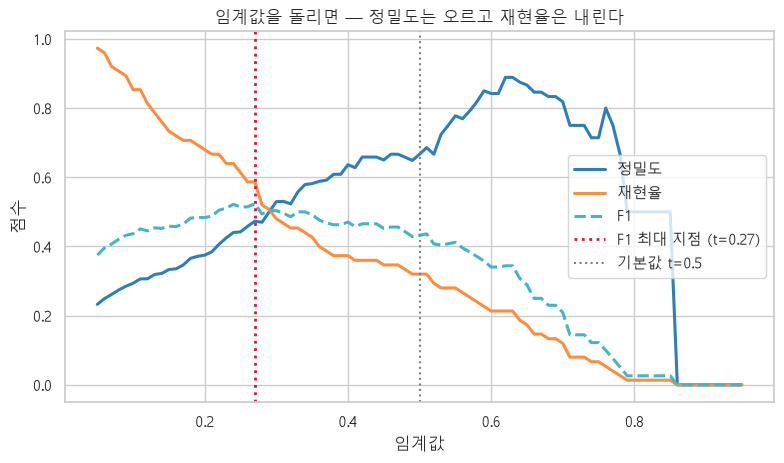

F1이 가장 높은 임계값 = 0.27 (F1 = 0.524)  ← 기본값 0.5보다 왼쪽입니다
→ 정밀도와 재현율이 정확히 반대로 움직입니다. 둘을 동시에 올리는 임계값은 없습니다.


In [36]:
# ─────────────────────────────────────────────
# [C16] Part 5 · 📊 데이터로 확인해 봅시다 — 손잡이를 돌려 보기
# 임계값에 따른 정밀도·재현율·F1 (실행하면 세 곡선이 한 그림에 그려집니다)
# ─────────────────────────────────────────────
ts = np.linspace(0.05, 0.95, 91)
p_list, r_list, f_list = [], [], []
for t in ts:
    p_t = (proba >= t).astype(int)
    p_list.append(precision_score(y_te, p_t, zero_division=0))
    r_list.append(recall_score(y_te, p_t))
    f_list.append(f1_score(y_te, p_t, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(ts, p_list, lw=2.2, label="정밀도", color="#2c7fb8")
ax.plot(ts, r_list, lw=2.2, label="재현율", color="#fd8d3c")
ax.plot(ts, f_list, lw=2.2, label="F1", color="#41b6c4", ls="--")
best_t = ts[int(np.argmax(f_list))]
ax.axvline(best_t, color="crimson", ls=":", lw=2,
           label=f"F1 최대 지점 (t={best_t:.2f})")
ax.axvline(0.5, color="gray", ls=":", lw=1.5, label="기본값 t=0.5")
ax.set_xlabel("임계값")
ax.set_ylabel("점수")
ax.set_title("임계값을 돌리면 — 정밀도는 오르고 재현율은 내린다")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

print(f"F1이 가장 높은 임계값 = {best_t:.2f} (F1 = {max(f_list):.3f})  ← 기본값 0.5보다 왼쪽입니다")
print("→ 정밀도와 재현율이 정확히 반대로 움직입니다. 둘을 동시에 올리는 임계값은 없습니다.")

👀 [C16] 결과읽기
이 데이터에서는 임계값이 높아질수록 정밀도는 대체로 오르고 재현율은 내려갑니다. 유한한 데이터에서는 정밀도가 구간별로 흔들릴 수 있으므로 항상 단조 증가한다고 단정하지 않습니다. 점선 F1의 최댓값은 정밀도와 재현율을 같은 비중으로 요약했을 때의 후보 운영점입니다.

회색 점선(기본값 0.5)이 붉은 점선(F1 최대)보다 오른쪽에 있음을 확인합니다. 기본값은 이 문제에서 필요 이상으로 보수적이었습니다.

그런데 F1 최대점이 정말 우리가 원하는 지점일까요? F1은 정밀도와 재현율을 동등하게 취급합니다. 하지만 모두플레이에서 고객을 잃는 손실과 쿠폰 한 장의 비용이 같을 리 없습니다. 비용을 넣어 다시 계산해야 합니다.

In [37]:
# ─────────────────────────────────────────────
# [C17] Part 5 · 📊 데이터로 확인해 봅시다 — 손잡이를 돌려 보기
# 비용으로 임계값 정하기 (실행하면 임계값별 총비용과 최소 지점이 나옵니다)
# ─────────────────────────────────────────────
# 모두플레이 마케팅팀이 알려준 숫자
COST_FN = 10   # 놓침 1건 = 이탈로 잃는 고객 생애가치 10만원
COST_FP = 2    # 헛경보 1건 = 불필요한 방어 쿠폰 2만원

rows = []
for t in np.arange(0.05, 0.85, 0.05):
    p_t = (proba >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_te, p_t).ravel()
    rows.append({
        "임계값": round(t, 2),
        "놓침(FN)": fn_t,
        "헛경보(FP)": fp_t,
        "총비용(만원)": fn_t * COST_FN + fp_t * COST_FP,
    })
cost = pd.DataFrame(rows)
print(f"놓침 1건 = {COST_FN}만원 / 헛경보 1건 = {COST_FP}만원 (비용비 {COST_FN // COST_FP}:1)")
print()
print(cost[cost["임계값"] <= 0.55].to_string(index=False))

opt = cost.loc[cost["총비용(만원)"].idxmin()]
print()
print(f"→ 총비용이 최소인 임계값 = {opt['임계값']:.2f}  (총비용 {int(opt['총비용(만원)'])}만원)")
print(f"  기본값 0.5의 총비용은 {int(cost.loc[cost['임계값'] == 0.5, '총비용(만원)'].iloc[0])}만원이었습니다.")

놓침 1건 = 10만원 / 헛경보 1건 = 2만원 (비용비 5:1)

 임계값  놓침(FN)  헛경보(FP)  총비용(만원)
0.05       2      241      502
0.10      11      154      418
0.15      20      110      420
0.20      24       85      410
0.25      29       58      406
0.30      39       32      454
0.35      43       23      476
0.40      47       16      502
0.45      49       14      518
0.50      51       12      534
0.55      54        6      552

→ 총비용이 최소인 임계값 = 0.25  (총비용 406만원)
  기본값 0.5의 총비용은 534만원이었습니다.


👀 [C17] 결과읽기
이 예제의 비용 가정에서는 총비용이 U자 형태로 나타납니다. 임계값이 너무 낮으면 헛경보가 폭발하고(t=0.05에서 502만원), 너무 높으면 놓침이 쌓입니다(t=0.5에서 534만원). 그 사이 t=0.25에서 406만원으로 최소가 됩니다.

이제 보고할 문장이 완전히 달라집니다.

"임계값을 0.25로 설정했습니다. 놓침 1건을 10만원, 헛경보 1건을 2만원으로 놓고 계산했을 때 예상 손실이 406만원으로 최소이며, 기본값 0.5(534만원)보다 128만원 낮습니다."

임계값과 함께 비용 가정을 기록해야 결과를 재검토할 수 있습니다. 숫자와 가정이 함께 있으므로, 나중에 쿠폰 단가가 바뀌면 계산을 다시 해서 임계값을 갱신할 수 있습니다.

💡 핵심짚기
이 데이터와 탐색 범위에서는 비용비(C 
FN
​
 :C 
FP
​
 )가 클수록 비용 최소 임계값이 낮아집니다. 놓침이 아플수록 그물을 크게 던지는 것이 맞기 때문입니다. 따라서 임계값은 모델 성능뿐 아니라 비즈니스 비용을 반영해 결정합니다.

이제 두 번째 손잡이인 class_weight를 확인합니다. 지난 시간 배운 계층 교차 검증으로 전후를 비교합니다.

⚠️ 주의하기 — 검증 데이터에서 선택하기
이 노트북에서는 개념을 비교하기 위해 테스트 데이터에서 비용 곡선을 그렸습니다. 실제 업무에서는 검증 데이터 또는 교차 검증의 OOF(Out-of-Fold) 예측으로 임계값을 정하고, 테스트 데이터는 최종 평가에 한 번만 사용합니다. 또한 이 비용식은 TP의 쿠폰 비용과 유지 효과를 이미 순편익에 반영했다고 가정한 단순 모형입니다.

In [38]:
# ─────────────────────────────────────────────
# [C18] Part 5 · 📊 데이터로 확인해 봅시다 — 손잡이를 돌려 보기
# class_weight 보정 전후 — 계층 5겹 교차 검증 (실행하면 네 지표의 전후 비교표가 나옵니다)
# ─────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = []
for cw, label in [(None, "보정 없음"), ("balanced", "class_weight='balanced'")]:
    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, class_weight=cw, random_state=RANDOM_STATE),
    )
    rows.append({
        "설정": label,
        "재현율": cross_val_score(pipe, X, y, cv=cv, scoring="recall").mean(),
        "정밀도": cross_val_score(pipe, X, y, cv=cv, scoring="precision").mean(),
        "F1": cross_val_score(pipe, X, y, cv=cv, scoring="f1").mean(),
        "AP": cross_val_score(pipe, X, y, cv=cv, scoring="average_precision").mean(),
    })
cw_compare = pd.DataFrame(rows)
print("계층 5겹 교차 검증 평균")
print(cw_compare.round(3).to_string(index=False))
print()
d_recall = cw_compare["재현율"].iloc[1] - cw_compare["재현율"].iloc[0]
d_prec = cw_compare["정밀도"].iloc[1] - cw_compare["정밀도"].iloc[0]
d_ap = cw_compare["AP"].iloc[1] - cw_compare["AP"].iloc[0]
print(f"→ 재현율 변화: {d_recall:+.3f}   (약 {cw_compare['재현율'].iloc[1] / cw_compare['재현율'].iloc[0]:.1f}배)")
print(f"  정밀도 변화: {d_prec:+.3f}   ← 재현율을 산 값입니다")
print(f"  AP 변화: {d_ap:+.3f}   ← 순위 요약 성능의 변화를 함께 확인합니다")

계층 5겹 교차 검증 평균
                     설정  재현율   정밀도    F1    AP
                  보정 없음 0.29 0.672 0.405 0.532
class_weight='balanced' 0.81 0.297 0.434 0.534

→ 재현율 변화: +0.520   (약 2.8배)
  정밀도 변화: -0.375   ← 재현율을 산 값입니다
  AP 변화: +0.002   ← 순위 요약 성능의 변화를 함께 확인합니다


가장 중요한 줄은 맨 아래입니다. AP가 0.532에서 0.534로 거의 변하지 않았습니다.

AP는 여러 재현율 수준에서 정밀도를 요약하며 예측 순위의 품질을 반영합니다. 이 실험에서 AP가 거의 같다는 것은 두 설정의 순위 요약 성능이 비슷했다는 뜻입니다. 그러나 class_weight는 학습 손실을 바꾸므로 계수와 예측 순위도 달라질 수 있습니다. 임계값만 옮긴 것과 동일하다고 단정할 수 없습니다.

첫째, class_weight는 모든 지표를 함께 올리는 스위치가 아닙니다. 이 실험에서는 재현율이 오르고 정밀도가 낮아졌습니다. 채택 여부는 검증 지표와 오류 비용을 함께 보고 판단합니다.

둘째, 어떤 지표를 우선하느냐에 따라 채택 판단이 달라집니다.

- 재현율을 우선하면 balanced 설정이 유리합니다(0.290 → 0.810).
- 정밀도를 우선하면 보정하지 않은 설정이 유리합니다(0.672 → 0.297).
- F1 차이는 +0.030이며, 변동성을 함께 확인해야 합니다.
- AP 차이는 +0.002로 두 설정의 순위 요약 성능이 비슷합니다.

운영 목적과 오류 비용이 판단 기준이 됩니다. 모두플레이처럼 놓침(고객 상실)이 헛경보(쿠폰)보다 5배 비싸다면 재현율 쪽 결론이 맞습니다. 반대로 쿠폰 예산이 빡빡하다면 정밀도 쪽이 맞습니다.

[문제]
1) [C17]의 비용 계산을 쿠폰 단가가 오른 상황으로 다시 계산합니다.
   COST_FN = 10 (그대로), COST_FP = 5 (2만원 → 5만원)
   총비용이 최소가 되는 임계값이 어디로 옮겨갑니까?
2) 반대로 고객 생애가치가 30만원으로 재평가됐다면(COST_FN = 30, COST_FP = 2)
   최적 임계값은 어디로 옮겨갑니까?
3) 1번과 2번의 결과를 보고, "비용비와 최적 임계값의 관계"를 한 줄로 정리합니다.

In [44]:
# [C19] Part 5 · ⌨️ 백문이 불여일타! (5)
# ⌨️ 백문이 불여일타! (5) — 비용이 바뀌면 최적 임계값은 어디로 가는가

scenarios = [(10, 2, "기준 (5:1)"), (10, 5, "쿠폰 인상 (2:1)"), (30, 2, "생애가치 상향 (15:1)")]

# 여기에 코드를 작성하세요

def myfun (COST_FN, COST_FP, label):
    rows = []
    for t in np.arange(0.05, 0.85, 0.05):
        p_t = (proba >= t).astype(int)
        tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_te, p_t).ravel()
        rows.append({
        "임계값": round(t, 2),
        "놓침(FN)": fn_t,
        "헛경보(FP)": fp_t,
        "총비용(만원)": fn_t * COST_FN + fp_t * COST_FP,
        })
        cost = pd.DataFrame(rows)
    print(f"놓침 1건 = {COST_FN}만원 / 헛경보 1건 = {COST_FP}만원 (비용비 {COST_FN // COST_FP}:1)")
    print()
    print(cost[cost["임계값"] <= 0.55].to_string(index=False))
    opt = cost.loc[cost["총비용(만원)"].idxmin()]
    print()
    print(f"→ 총비용이 최소인 임계값 = {opt['임계값']:.2f}  (총비용 {int(opt['총비용(만원)'])}만원)")
    print(f"  기본값 0.5의 총비용은 {int(cost.loc[cost['임계값'] == 0.5, '총비용(만원)'].iloc[0])}만원이었습니다.")

In [45]:
for COST_FN, COST_FP, label in scenarios:
    print(f"=== {label} ===")
    myfun(COST_FN, COST_FP, label)
    print()

=== 기준 (5:1) ===
놓침 1건 = 10만원 / 헛경보 1건 = 2만원 (비용비 5:1)

 임계값  놓침(FN)  헛경보(FP)  총비용(만원)
0.05       2      241      502
0.10      11      154      418
0.15      20      110      420
0.20      24       85      410
0.25      29       58      406
0.30      39       32      454
0.35      43       23      476
0.40      47       16      502
0.45      49       14      518
0.50      51       12      534
0.55      54        6      552

→ 총비용이 최소인 임계값 = 0.25  (총비용 406만원)
  기본값 0.5의 총비용은 534만원이었습니다.

=== 쿠폰 인상 (2:1) ===
놓침 1건 = 10만원 / 헛경보 1건 = 5만원 (비용비 2:1)

 임계값  놓침(FN)  헛경보(FP)  총비용(만원)
0.05       2      241     1225
0.10      11      154      880
0.15      20      110      750
0.20      24       85      665
0.25      29       58      580
0.30      39       32      550
0.35      43       23      545
0.40      47       16      550
0.45      49       14      560
0.50      51       12      570
0.55      54        6      570

→ 총비용이 최소인 임계값 = 0.35  (총비용 545만원)
  기본값 0.5의 총비용은 570만원이었습니다.

=== 생애가치 상향

In [ ]:
# [C20] ❓ 오늘의 퀴즈 · 코드 퀴즈
# 코드 퀴즈 — 빈칸(____)을 채워 임계값 0.35의 지표 계산

# threshold = 0.35
# pred_q = (proba >= ____).astype(int)          # 확률을 임계값으로 자르기
# print("재현율:", ____(y_te, pred_q))          # 놓침을 보는 지표
# print("정밀도:", ____(y_te, pred_q))          # 헛경보를 보는 지표

# 여기에 코드를 작성하세요